# Sentiment Analysis on IMDB Movie Reviews

## Section 1: Import Libraries
Importing all required libraries for data manipulation, visualization, text processing, and machine learning.

In [19]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import re
import string
import nltk
from nltk.corpus import stopwords

# Feature engineering
from sklearn.feature_extraction.text import TfidfVectorizer

# Model training
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Download NLTK stopwords
nltk.download('stopwords', quiet=True)

# Plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## Section 2: Load Dataset

Load the IMDB dataset and perform initial exploration to understand its structure, size, and class distribution.

In [20]:
# Load the dataset
df = pd.read_csv("IMDB Dataset.csv")

# Preview first 5 rows
print("First 5 rows:")
df.head()

First 5 rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [21]:
# Dataset shape
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset Shape: 50000 rows × 2 columns


In [22]:
# Dataset info
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [23]:
# Sentiment class distribution
print("Sentiment Value Counts:")
print(df['sentiment'].value_counts(normalize=True))
print(f"\nMissing values:\n{df.isnull().sum()}")

Sentiment Value Counts:
sentiment
positive    0.5
negative    0.5
Name: proportion, dtype: float64

Missing values:
review       0
sentiment    0
dtype: int64


## Section 3: Basic Exploratory Data Analysis (EDA)

Understanding the data through visualizations and statistics before building any model.

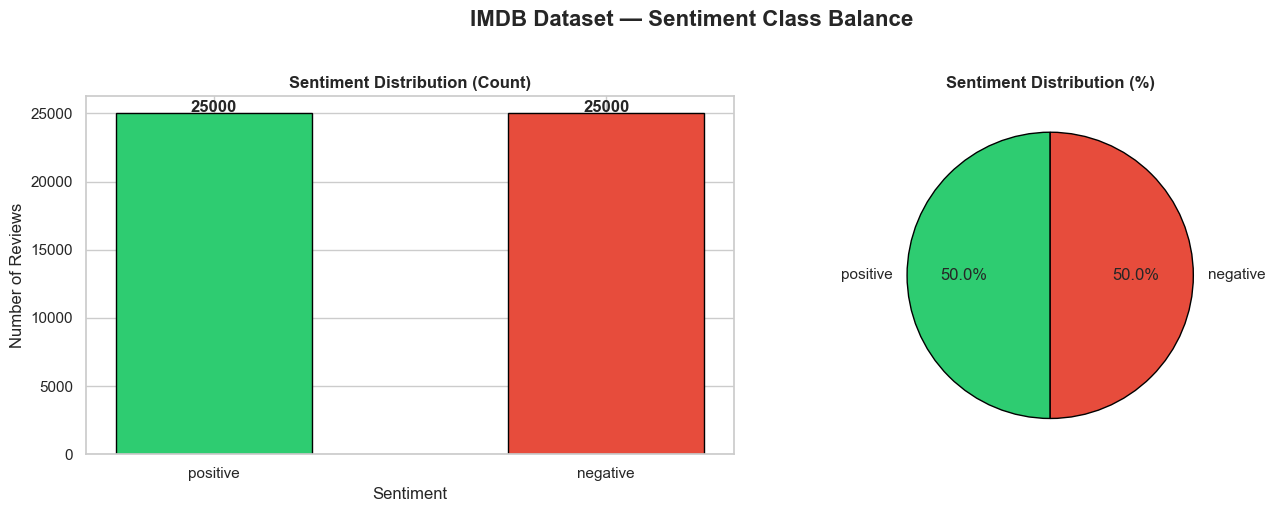

In [24]:
# --- Plot 1: Sentiment Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sentiment_counts = df['sentiment'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title("Sentiment Distribution (Count)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Number of Reviews")
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'black'})
axes[1].set_title("Sentiment Distribution (%)", fontsize=12, fontweight='bold')

plt.suptitle("IMDB Dataset — Sentiment Class Balance", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Review Length Statistics:
             count    mean     std   min    25%    50%     75%      max
sentiment                                                              
negative   25000.0  1294.1   945.9  32.0  706.0  973.0  1567.2   8969.0
positive   25000.0  1324.8  1031.5  65.0  691.0  968.0  1614.0  13704.0


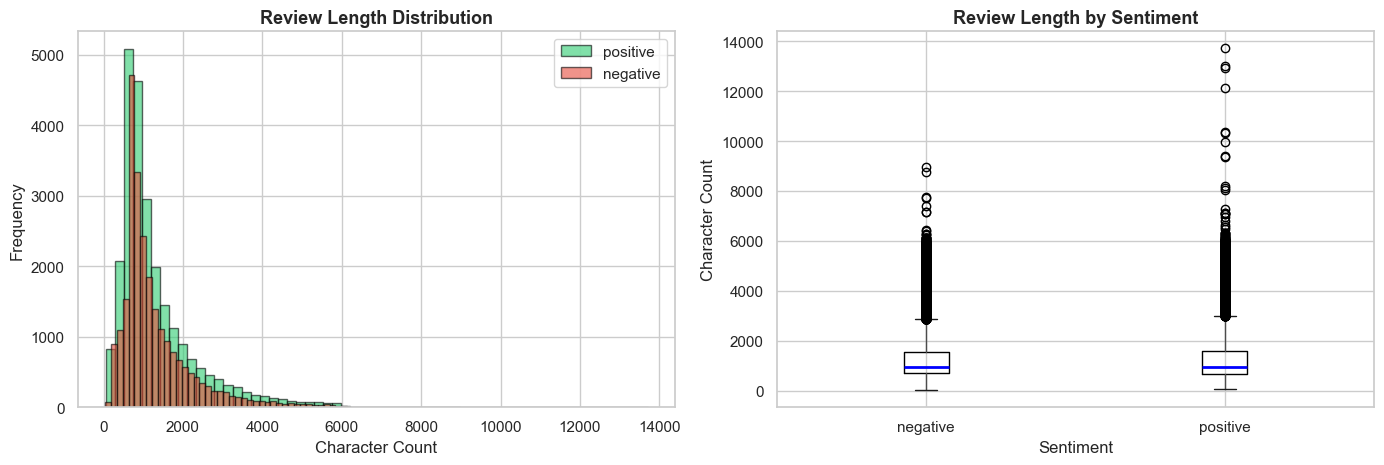

In [25]:
# --- Review Length Analysis ---
df['review_length'] = df['review'].apply(len)
# print(df['review_length'])

print("Review Length Statistics:")
print(df.groupby('sentiment')['review_length'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for sentiment, color in zip(['positive', 'negative'], ['#2ecc71', '#e74c3c']):
    subset = df[df['sentiment'] == sentiment]['review_length']
    axes[0].hist(subset, bins=60, alpha=0.6, color=color, label=sentiment, edgecolor='black')
axes[0].set_title("Review Length Distribution", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Character Count")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Boxplot
df.boxplot(column='review_length', by='sentiment', ax=axes[1],
           boxprops=dict(color='black'), medianprops=dict(color='blue', linewidth=2))
axes[1].set_title("Review Length by Sentiment", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Character Count")
plt.suptitle("")

plt.tight_layout()
plt.show()

In [26]:
# --- Sample Longest Reviews ---
print("=== Longest POSITIVE Review (first 500 chars) ===")
longest_pos = df[df['sentiment'] == 'positive'].nlargest(1, 'review_length')['review'].values[0]
print(longest_pos[:500], "...\n")

print("=== Longest NEGATIVE Review (first 500 chars) ===")
longest_neg = df[df['sentiment'] == 'negative'].nlargest(1, 'review_length')['review'].values[0]
print(longest_neg[:500], "...")

=== Longest POSITIVE Review (first 500 chars) ===
Match 1: Tag Team Table Match Bubba Ray and Spike Dudley vs Eddie Guerrero and Chris Benoit Bubba Ray and Spike Dudley started things off with a Tag Team Table Match against Eddie Guerrero and Chris Benoit. According to the rules of the match, both opponents have to go through tables in order to get the win. Benoit and Guerrero heated up early on by taking turns hammering first Spike and then Bubba Ray. A German suplex by Benoit to Bubba took the wind out of the Dudley brother. Spike tried to he ...

=== Longest NEGATIVE Review (first 500 chars) ===
Some have praised _Atlantis:_The_Lost_Empire_ as a Disney adventure for adults. I don't think so--at least not for thinking adults.<br /><br />This script suggests a beginning as a live-action movie, that struck someone as the type of crap you cannot sell to adults anymore. The "crack staff" of many older adventure movies has been done well before, (think _The Dirty Dozen_) but _Atlantis_ re

## Section 4: Text Cleaning

Raw reviews contain noise: HTML tags, punctuation, numbers, and stopwords — all of which don't contribute to sentiment. We clean the text to keep only meaningful words.

**Cleaning Pipeline:**
1. Remove HTML tags (e.g., `<br />`)  
2. Remove punctuation and numbers  
3. Convert to lowercase  
4. Remove stopwords (e.g., "the", "is", "and")

In [27]:
# Define the text cleaning function
STOPWORDS = set(stopwords.words('english'))

def clean_text(text):
    # 1. Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)
    # 3. Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # 4. Convert to lowercase
    text = text.lower()
    # 5. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # 6. Remove stopwords
    tokens = text.split()
    tokens = [word for word in tokens if word not in STOPWORDS and len(word) > 2]
    return ' '.join(tokens)

# Test on a sample
sample_raw = df['review'][0][:300]
sample_clean = clean_text(sample_raw)
print("BEFORE CLEANING:")
print(sample_raw)
print("\nAFTER CLEANING:")
print(sample_clean)

BEFORE CLEANING:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru

AFTER CLEANING:
one reviewers mentioned watching episode hooked right exactly happened first thing struck brutality unflinching scenes violence set right word tru


In [28]:
# Apply cleaning to all reviews
print("Cleaning all reviews... (this may take a moment)")
df['clean_review'] = df['review'].apply(clean_text)
print(f"Done! Cleaned {len(df)} reviews.")

# Compare lengths before and after
df['clean_length'] = df['clean_review'].apply(len)
print(f"\nAverage length BEFORE cleaning: {df['review_length'].mean():.0f} chars")
print(f"Average length AFTER  cleaning: {df['clean_length'].mean():.0f} chars")
print(f"Noise removed: ~{(1 - df['clean_length'].mean()/df['review_length'].mean())*100:.1f}%")


Cleaning all reviews... (this may take a moment)
Done! Cleaned 50000 reviews.

Average length BEFORE cleaning: 1309 chars
Average length AFTER  cleaning: 809 chars
Noise removed: ~38.2%


## Section 5: Feature Engineering

### TF-IDF Vectorization

Machine learning models cannot work directly on raw text. We convert cleaned text into numerical features using **TF-IDF (Term Frequency–Inverse Document Frequency)**.

- **TF** — How often a word appears in a document  
- **IDF** — Penalizes words that appear in many documents (common but uninformative)  
- Result: each review becomes a vector of weighted word scores

We also encode labels: `positive → 1`, `negative → 0`

In [29]:
# Encode target labels: positive=1, negative=0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print("Label encoding:")
print(df[['sentiment', 'label']].drop_duplicates())

# Train/Test Split (80/20)
X = df['clean_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining samples : {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Testing  samples : {len(X_test)}  ({len(X_test)/len(df)*100:.1f}%)")

Label encoding:
  sentiment  label
0  positive      1
3  negative      0

Training samples : 40000 (80.0%)
Testing  samples : 10000  (20.0%)


In [31]:
# Fit TF-IDF Vectorizer on training data only (to avoid data leakage)
tfidf = TfidfVectorizer(
    max_features=50000,     # Keep top 50k words by TF-IDF score
    ngram_range=(1, 2),     # Unigrams + Bigrams (e.g., "not good")
    sublinear_tf=True       # Apply log normalization to TF
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("TF-IDF Matrix Shapes:")
print(f"  Training : {X_train_tfidf.shape}  → {X_train_tfidf.shape[0]} reviews × {X_train_tfidf.shape[1]} features")
print(f"  Testing  : {X_test_tfidf.shape}")

# Top 20 terms by average TF-IDF score
feature_names = tfidf.get_feature_names_out()
mean_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).flatten()
top20_idx = mean_tfidf.argsort()[::-1][:20]
print(f"\nTop 20 TF-IDF Features:")
print([feature_names[i] for i in top20_idx])

TF-IDF Matrix Shapes:
  Training : (40000, 50000)  → 40000 reviews × 50000 features
  Testing  : (10000, 50000)

Top 20 TF-IDF Features:
['movie', 'film', 'one', 'like', 'good', 'time', 'see', 'would', 'really', 'even', 'story', 'well', 'bad', 'great', 'much', 'get', 'people', 'movies', 'first', 'made']


## Section 6: Train Model — Logistic Regression

**Why Logistic Regression?**
- Fast and interpretable — great baseline for text classification
- Works well with high-dimensional sparse TF-IDF features
- Provides probability scores for each class

**Setup:**
- Split: 80% train / 20% test
- Solver: `lbfgs` with max 1000 iterations
- Multi-class: binary (`positive` vs `negative`)

In [32]:
# Train Logistic Regression
print("Training Logistic Regression model...")

lr_model = LogisticRegression(
    C=1.0,              # Regularization strength (smaller = stronger regularization)
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_tfidf, y_train)
print("Model training complete!")

Training Logistic Regression model...
Model training complete!


## Section 7: Model Evaluation

Evaluate the model on the held-out test set using:

| Metric | Description |
|---|---|
| **Accuracy** | % of correct predictions overall |
| **Precision** | Of predicted positives, how many are truly positive |
| **Recall** | Of actual positives, how many were caught |
| **F1-Score** | Harmonic mean of Precision & Recall |
| **Confusion Matrix** | Visual breakdown of TP, TN, FP, FN |

**Target:** Accuracy > 85% → Good baseline ✓

In [37]:
# Predictions
y_pred = lr_model.predict(X_test_tfidf)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("=" * 50)
print(f"  Test Accuracy : {acc * 100:.2f}%")
if acc >= 0.85:
    print("  Result        : GOOD BASELINE ✓ (Accuracy ≥ 85%)")
else:
    print("  Result        : Below target — consider tuning")
print("=" * 50)

# Classification Report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

  Test Accuracy : 90.45%
  Result        : GOOD BASELINE ✓ (Accuracy ≥ 85%)

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      5000
    Positive       0.90      0.92      0.91      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



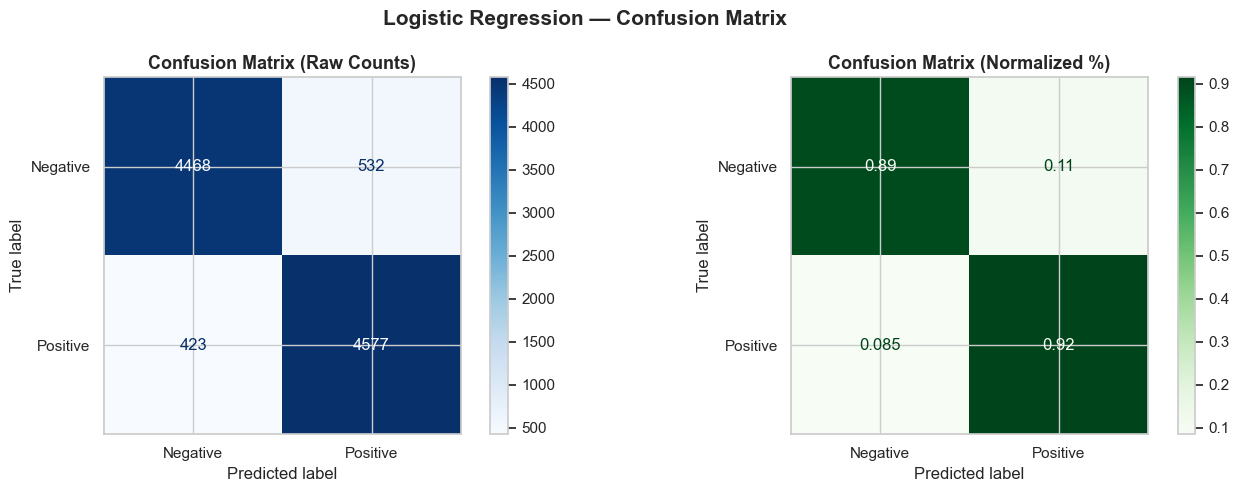


True  Negatives (Correctly predicted Negative): 4468
False Positives (Negative predicted as Positive): 532
False Negatives (Positive predicted as Negative): 423
True  Positives (Correctly predicted Positive): 4577


In [38]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Standard confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(ax=axes[0], colorbar=True, cmap='Blues')
axes[0].set_title("Confusion Matrix (Raw Counts)", fontsize=13, fontweight='bold')

# Normalized confusion matrix
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['Negative', 'Positive'])
disp_norm.plot(ax=axes[1], colorbar=True, cmap='Greens')
axes[1].set_title("Confusion Matrix (Normalized %)", fontsize=13, fontweight='bold')

plt.suptitle("Logistic Regression — Confusion Matrix", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary stats from confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue  Negatives (Correctly predicted Negative): {tn}")
print(f"False Positives (Negative predicted as Positive): {fp}")
print(f"False Negatives (Positive predicted as Negative): {fn}")
print(f"True  Positives (Correctly predicted Positive): {tp}")

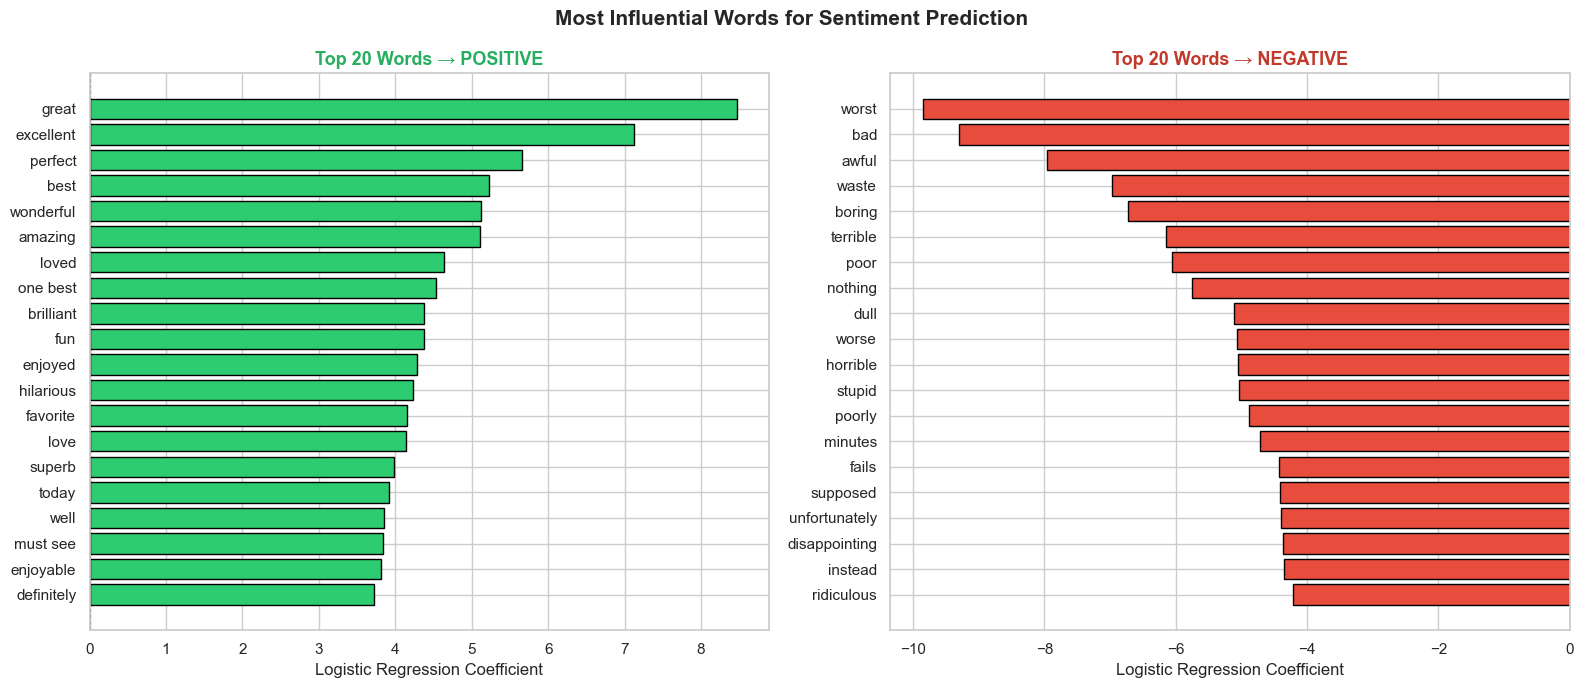

In [39]:
# --- Top Predictive Words ---
# Logistic Regression coefficients tell us which words push toward positive/negative
coef = lr_model.coef_[0]
top_n = 20

top_positive_idx = coef.argsort()[-top_n:][::-1]
top_negative_idx = coef.argsort()[:top_n]

top_positive_words = [(feature_names[i], coef[i]) for i in top_positive_idx]
top_negative_words = [(feature_names[i], coef[i]) for i in top_negative_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Positive words
words_p, scores_p = zip(*top_positive_words)
axes[0].barh(words_p[::-1], scores_p[::-1], color='#2ecc71', edgecolor='black')
axes[0].set_title(f"Top {top_n} Words → POSITIVE", fontsize=13, fontweight='bold', color='#27ae60')
axes[0].set_xlabel("Logistic Regression Coefficient")
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')

# Negative words
words_n, scores_n = zip(*top_negative_words)
axes[1].barh(words_n[::-1], scores_n[::-1], color='#e74c3c', edgecolor='black')
axes[1].set_title(f"Top {top_n} Words → NEGATIVE", fontsize=13, fontweight='bold', color='#c0392b')
axes[1].set_xlabel("Logistic Regression Coefficient")
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')

plt.suptitle("Most Influential Words for Sentiment Prediction", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Live Prediction Demo

Test the trained model on custom review text.

In [50]:
def predict_sentiment(review_text):
    """
    Predicts sentiment of a given review string.
    Returns label and confidence probability.
    """
    cleaned = clean_text(review_text)
    vectorized = tfidf.transform([cleaned])
    prediction = lr_model.predict(vectorized)[0]
    probability = lr_model.predict_proba(vectorized)[0]
    label = "POSITIVE 😊" if prediction == 1 else "NEGATIVE 😞"
    confidence = probability[prediction] * 100
    print(f"Review   : {review_text[:120]}...")
    print(f"Sentiment: {label}")
    print(f"Confidence: {confidence:.2f}%")
    print("-" * 60)

# Test cases
test_reviews = [
    # "This movie was absolutely fantastic! The acting was superb and the story kept me engaged throughout. Highly recommend!",
    # "Terrible film. Complete waste of time and money. The plot made no sense and the actors were awful.",
    # "It was an okay movie. Not great, not terrible. Some parts were interesting but overall it was just average.",
    # "One of the best films I have ever seen. A true masterpiece with brilliant cinematography and outstanding performances.",
    # "I hated every second of this movie. Boring, predictable, and completely disappointing."
    "The movie started very slow, but the second half was absolutely brilliant.","This movie is not good"
]

print("=" * 60)
print("         SENTIMENT ANALYSIS — LIVE PREDICTIONS")
print("=" * 60 + "\n")
for review in test_reviews:
    predict_sentiment(review)

         SENTIMENT ANALYSIS — LIVE PREDICTIONS

Review   : The movie started very slow, but the second half was absolutely brilliant....
Sentiment: NEGATIVE 😞
Confidence: 55.03%
------------------------------------------------------------
Review   : This movie is not good...
Sentiment: POSITIVE 😊
Confidence: 82.74%
------------------------------------------------------------
